In [121]:
import matplotlib.pyplot as plt
import numpy as np

# ----- Assumed experimental statistics (hypothetical, consistent with appendix) -----
approaches = [
    "A1: Fine-tuning",
    "A2: Prompting",
    "A3: Instr. Tuning",
    "A3: k-Instr. Tuning + RAG",
    "A4: SFT + DPO + RAG"
]

# Higher is better
accuracy = np.array([0.73, 0.72, 0.87, 0.99, 0.98])

# Training time in hours (wall-clock)
training_time = np.array([3.2, 0.1, 7.2, 7.2, 9.5])

# GPU count used during training
gpu_count_train = np.array([1, 0, 1, 4, 1])
gpu_count_inf = np.array([1, 1, 1, 4, 1]) 

import numpy as np

# Data
accuracy = np.array([0.73, 0.72, 0.87, 0.99, 0.98])
training_time = np.array([3.2, 0.1, 7.2, 7.2, 9.5])
gpu_total = gpu_count_train + gpu_count_inf  # [2, 1, 2, 8, 2]

# Normalize (higher better cho tất cả)
norm_accuracy = accuracy  # đã 0-1

# Invert time và gpu vì thấp tốt → higher better
max_time = training_time.max()
norm_time = 1 - (training_time / max_time)  # 0 (tệ nhất) đến 1 (tốt nhất)

max_gpu = gpu_total.max()
norm_gpu = 1 - (gpu_total / max_gpu)

# Robustness / Overall score (higher better), trọng số có thể điều chỉnh
robustness = norm_accuracy + 0.5 * norm_time # + 0.5 * norm_gpu

# Bubble size ∝ robustness (lớn = tốt)
robust_min = robustness.min()
robust_max = robustness.max()
bubble_size = 150 + (robustness - robust_min) / (robust_max - robust_min) * 2050

In [120]:
robustness

array([1.06157895, 1.21473684, 0.99105263, 1.11105263, 0.98      ])

In [96]:
norm_time

array([0.66315789, 0.98947368, 0.24210526, 0.24210526, 0.        ])

In [101]:
norm_gpu

array([0.75 , 0.875, 0.75 , 0.   , 0.75 ])

In [94]:
bubble_size

array([530.78947368, 607.36842105, 495.52631579, 555.52631579,
       490.        ])

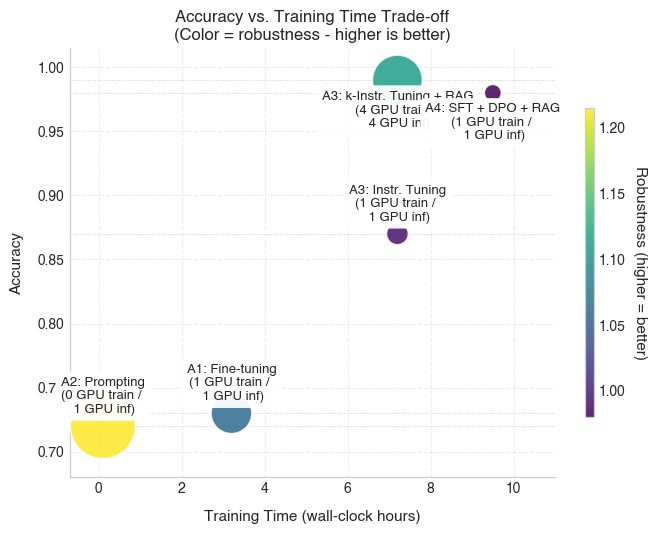

In [123]:
# ─── Style ───────────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans', 'Liberation Sans'],
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'grid.alpha': 0.35,
    'grid.linestyle': '--',
    'axes.linewidth': 0.9,
    'axes.labelpad': 8,
    'figure.constrained_layout.use': False,
    'savefig.dpi': 300
})

# ─── Plot ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8.2, 5.8))

# Light horizontal reference lines
for y in accuracy:
    ax.axhline(y, color='gray', lw=0.6, ls=':', alpha=0.45, zorder=1)

# Main scatter - color now by ROBUSTNESS
sc = ax.scatter(
    training_time, accuracy,
    s=bubble_size,
    c=robustness,                    # ← changed: color by robustness
    cmap='viridis',                  # viridis: dark purple (low) → yellow (high)
    # Alternative good options:
    # cmap='magma',     # black → purple → yellow
    # cmap='inferno',
    # cmap='plasma',
    # cmap='YlGnBu_r',  # light → dark (reverse = higher better)
    alpha=0.85,
    edgecolors='white',
    linewidth=1.1,
    zorder=3
)

# Labels
for i, label in enumerate(approaches):
    x, y = training_time[i], accuracy[i]
    offset = 0.008 if y < 0.90 else -0.008
    va = 'bottom' if offset > 0 else 'top'
    
    ax.text(
        x, y + offset,
        f"{label}\n({gpu_count_train[i]} GPU train / \n {gpu_count_inf[i]} GPU inf)",
        ha='center', va=va,
        fontsize=9.5,
        linespacing=1.1,
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.94, boxstyle='round,pad=0.38'),
        zorder=10
    )

# ─── Axes & styling ──────────────────────────────────────────────────────
ax.set_xlim(-0.7, 11)
ax.set_ylim(0.68, 1.015)

ax.set_xlabel("Training Time (wall-clock hours)", labelpad=10)
ax.set_ylabel("Accuracy", labelpad=10)

ax.set_title(
    "Accuracy vs. Training Time Trade-off\n"
    "(Color = robustness - higher is better)",
    # fontsize=12.5, pad=18, fontweight='medium'
)

# Colorbar (now showing robustness)
cbar = plt.colorbar(sc, ax=ax, shrink=0.72, aspect=35, pad=0.05)
cbar.set_label("Robustness (higher = better)", rotation=270, labelpad=15)

ax.grid(True, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.subplots_adjust(left=0.12, right=0.86, top=0.88, bottom=0.14)

plt.show()